Dataset Loaded Successfully
Dataset Shape: (50000, 30)
Detected Target Column: Is_Fraudulent
Feature Shape: (50000, 29)
Target Shape: (50000,)

Target Distribution:
Is_Fraudulent
0    25207
1    24793
Name: count, dtype: int64

Training Size: (40000, 29)
Testing Size: (10000, 29)

Training Logistic Regression...

Training Decision Tree...

Training KNN...

Results Table
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.9999     0.9998  1.0000    0.9999
1        Decision Tree    0.9999     0.9998  1.0000    0.9999
2                  KNN    0.6101     0.6185  0.5433    0.5784

Table Saved Successfully
C:\Users\dheer\Desktop\ML\RQ1_table.csv


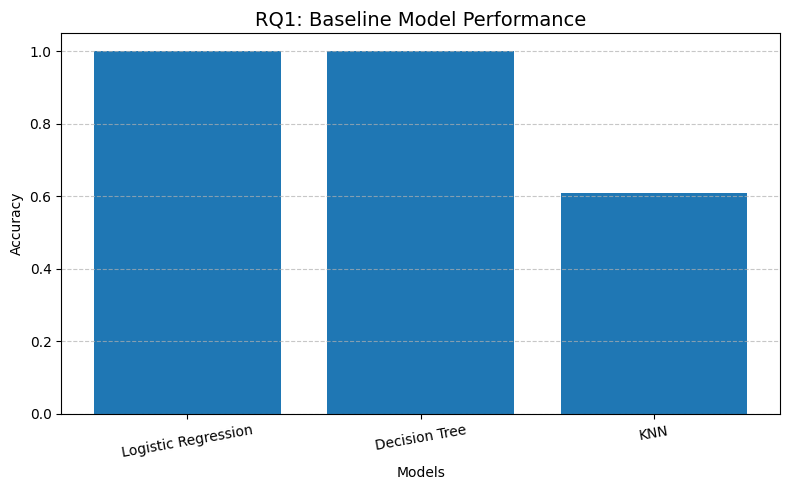


Figure Saved Successfully
C:\Users\dheer\Desktop\ML\RQ1_figure.pdf

RQ1 Completed Successfully


In [1]:
# ============================================
# RQ1: Baseline Models (FINAL VERSION)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# --------------------------------------------
# Step 1: Load Cleaned Dataset
# --------------------------------------------

df = pd.read_csv(
    r"C:\Users\dheer\Desktop\ML\cleaned_dataset.csv"
)

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)

# --------------------------------------------
# Step 2: Detect Target Column
# --------------------------------------------

target_col = None

for col in df.columns:
    if 'fraud' in col.lower():
        target_col = col
        break

print("Detected Target Column:", target_col)

if target_col is None:
    raise Exception("Fraud column not found")

# --------------------------------------------
# Step 3: Define Features and Target
# --------------------------------------------

y = df[target_col]
X = df.drop(columns=[target_col])

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

# --------------------------------------------
# Step 4: Train-Test Split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Size:", X_train.shape)
print("Testing Size:", X_test.shape)

# --------------------------------------------
# Step 5: Define Baseline Models
# --------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

# --------------------------------------------
# Step 6: Train and Evaluate Models
# --------------------------------------------

results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

# --------------------------------------------
# Step 7: Create Results Table
# --------------------------------------------

df_results = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

# Round values
df_results = df_results.round(4)

print("\nResults Table")
print(df_results)

# --------------------------------------------
# Step 8: Save Results Table
# --------------------------------------------

table_path = r"C:\Users\dheer\Desktop\ML\RQ1_table.csv"

df_results.to_csv(
    table_path,
    index=False
)

print("\nTable Saved Successfully")
print(table_path)

# --------------------------------------------
# Step 9: Create Figure
# --------------------------------------------

plt.figure(figsize=(8,5))

plt.bar(
    df_results['Model'],
    df_results['Accuracy']
)

plt.title(
    'RQ1: Baseline Model Performance',
    fontsize=14
)

plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.xticks(rotation=10)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()

# --------------------------------------------
# Step 10: Save Figure
# --------------------------------------------

figure_path = r"C:\Users\dheer\Desktop\ML\RQ1_figure.pdf"

plt.savefig(
    figure_path,
    bbox_inches='tight'
)

plt.show()

print("\nFigure Saved Successfully")
print(figure_path)

# --------------------------------------------
# Completed
# --------------------------------------------

print("\nRQ1 Completed Successfully")